<a href="https://colab.research.google.com/github/Jaelibj/JaeliJaussi/blob/main/Module_7_RandomForest_and_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Libraries
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc)

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

# Download latest version
path = kagglehub.dataset_download("reeljojo/default-on-their-credit-card")

print("Path to dataset files:", path)
print(os.listdir(path))


# Load Dataset
file_path = os.path.join(path, "default of credit card clients.xls")
df = pd.read_excel(file_path, header=1)


# Clean column names
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns.tolist())




Using Colab cache for faster access to the 'default-on-their-credit-card' dataset.
Path to dataset files: /kaggle/input/default-on-their-credit-card
['default of credit card clients.csv', 'default of credit card clients.xls']
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ... 

In [14]:
# Features
y = df['default payment next month']
X = df.drop(['default payment next month', 'ID'], axis=1)

# Train/Split Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Scale Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [15]:
# Parameters
param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1)

search.fit(X_train_raw, y_train)
print("Best Parameters:", search.best_params_)
rf_model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


In [16]:
# Train Model
rf_model.fit(X_train_raw, y_train)

# Predictions
rf_probs = rf_model.predict_proba(X_test_raw)[:, 1]

#for t in [0.5, 0.4, 0.3, 0.2]:
#    preds = (rf_probs >= t).astype(int)
#    print(f"\nThreshold: {t}")
#    print(confusion_matrix(y_test, preds))

rf_pred_adjusted = (rf_probs >= threshold).astype(int)

# Evaluation
print("Adjusted Threshold Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred_adjusted))

print("\nAdjusted Threshold Classification Report:")
print(classification_report(y_test, rf_pred_adjusted))

# Commpare
rf_pred = rf_model.predict(X_test_raw)

print("\nDefault Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nDefault Classification Report:\n", classification_report(y_test, rf_pred))


Adjusted Threshold Confusion Matrix:
[[2115 2572]
 [ 179 1134]]

Adjusted Threshold Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.45      0.61      4687
           1       0.31      0.86      0.45      1313

    accuracy                           0.54      6000
   macro avg       0.61      0.66      0.53      6000
weighted avg       0.79      0.54      0.57      6000


Default Random Forest Accuracy: 0.7786666666666666

Default Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86      4687
           1       0.50      0.57      0.53      1313

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



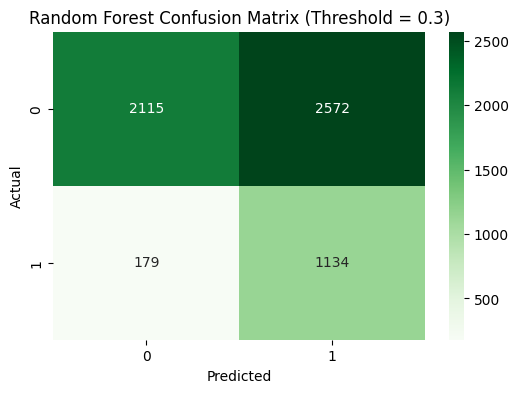

Random Forest AUC: 0.7779588695604556


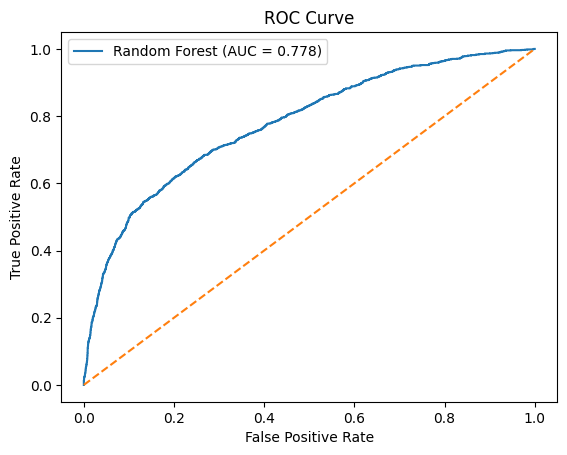

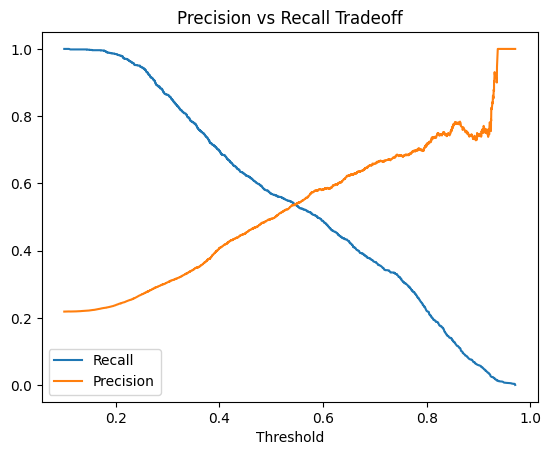

In [17]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred_adjusted)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix (Threshold = 0.3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

print("Random Forest AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall vs Threshold
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)

plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, precision[:-1], label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision vs Recall Tradeoff")
plt.show()


      Feature  Importance
5       PAY_0    0.248303
6       PAY_2    0.102158
8       PAY_4    0.062042
7       PAY_3    0.054719
0   LIMIT_BAL    0.048252
17   PAY_AMT1    0.041703
10      PAY_6    0.041529
18   PAY_AMT2    0.039590
11  BILL_AMT1    0.038333
20   PAY_AMT4    0.034764


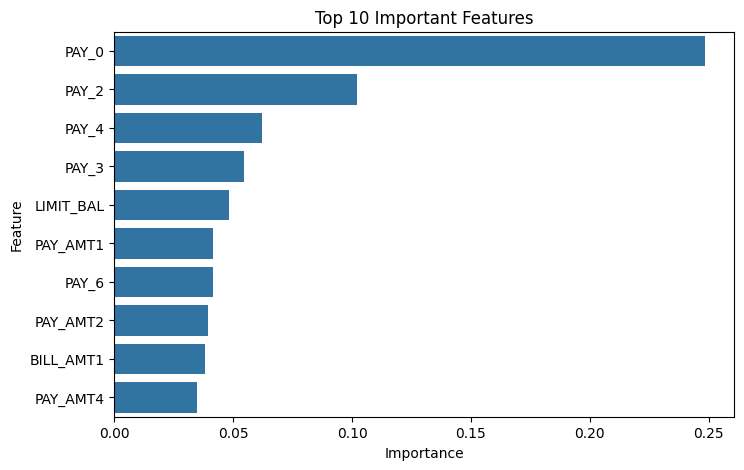

In [18]:
# Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance.head(10))

# Visual
plt.figure(figsize=(8,5))
sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature")
plt.title("Top 10 Important Features")
plt.show()